# Iterated Polygons & Convergence to Ellipses

## The Midpoint Map

Given a polygon $P = (z_0, z_1, \ldots, z_{k-1})$ in the complex plane, the **midpoint map** $M$ produces a new polygon $P' = M(P)$ by replacing each vertex with the midpoint of the edge connecting it to its successor:
$$z_j' = \frac{z_j + z_{j+1}}{2}, \quad \text{indices mod } k$$

## Spectral Analysis

The midpoint map is a **circulant linear operator** on $\mathbb{R}^{2k}$. Its eigenvalues are obtained via the DFT: the $j$-th Fourier mode $e^{2\pi i j n / k}$ is scaled by the factor:
$$\lambda_j = \frac{1 + e^{2\pi i j/k}}{2} = \cos\left(\frac{\pi j}{k}\right) e^{i\pi j/k}$$

Since $|\lambda_j| = \cos(\pi j/k) < 1$ for $j \neq 0$, all non-constant modes **shrink** at each step. The $j=0$ mode (the centroid) is preserved, and the $j=1$ (fundamental frequency) mode decays slowest.

## Convergence to an Ellipse

After $m$ iterations, only the modes $j = 0, 1, k-1$ survive (the rest decay exponentially). The $j=1$ and $j=k-1$ modes correspond to counter-rotating frequencies, whose superposition traces an **ellipse** centered at the centroid of the original polygon. This is why all polygons converge to elliptical shapes under iterated midpointing.

## General Affine Averaging

The midpoint rule is a special case of the **weighted average**:
$$z_j' = (1-s) z_j + s \cdot z_{j+1}$$

For $s = 1/2$ one gets midpoints; for other values of $s$, the convergence shape changes. This family interpolates between the original polygon ($s=0$) and a cyclic shift ($s=1$).

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

### Iterated midpoint map

We implement the midpoint map and visualize the evolution of a polygon. The colors go from initial (blue) to final (red).

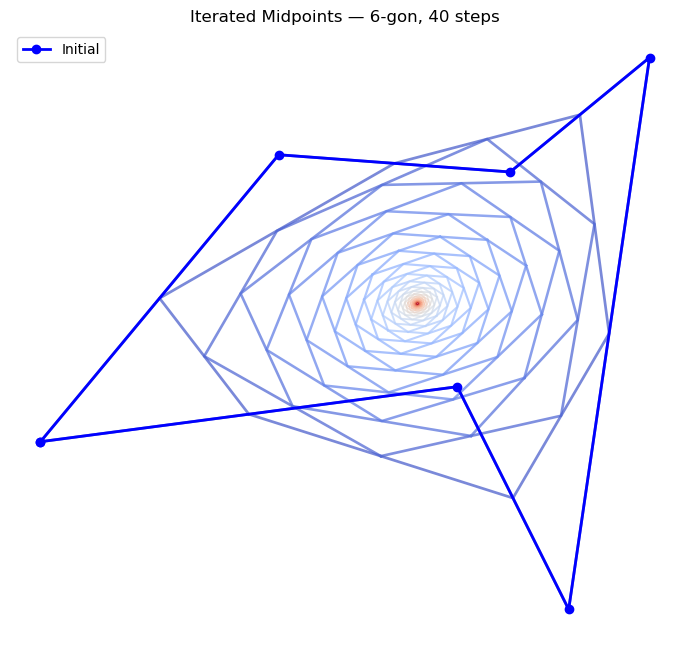

In [2]:
def midpoint_step(z, s=0.5):
    """One step of the weighted midpoint map: z -> (1-s)*z + s*roll(z, -1)."""
    return (1 - s) * z + s * np.roll(z, -1)

def iterate_polygon(z0, n_iter, s=0.5):
    """Return list of polygon states after 0, 1, ..., n_iter steps."""
    polys = [z0.copy()]
    z = z0.copy()
    for _ in range(n_iter):
        z = midpoint_step(z, s=s)
        polys.append(z.copy())
    return polys

# Initial polygon: random k-gon
rng = np.random.default_rng(42)
k = 6
z0 = rng.random(k) + 1j * rng.random(k)
# Sort by angle for nicer display
z0 = z0[np.argsort(np.angle(z0 - z0.mean()))]
z0 = z0 - z0.mean()  # center

n_iter = 40
polys = iterate_polygon(z0, n_iter)

# Show evolution
fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.coolwarm(np.linspace(0, 1, n_iter + 1))
for i, (poly, col) in enumerate(zip(polys, colors)):
    z_closed = np.append(poly, poly[0])
    ax.plot(z_closed.real, z_closed.imag, '-', color=col,
            lw=max(0.3, 2.0 - 0.04*i), alpha=0.7)

# Mark initial vertices
ax.plot(np.append(z0.real, z0.real[0]),
        np.append(z0.imag, z0.imag[0]), 'b.-', ms=12, lw=2, label='Initial')

ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Iterated Midpoints — {k}-gon, {n_iter} steps')
ax.legend()
plt.tight_layout(); plt.savefig('iterated_poly.png', dpi=100, bbox_inches='tight'); plt.show()

### Multiple polygon shapes

We apply the midpoint iteration to polygons with different numbers of vertices: triangle (3), square (4), hexagon (6), octagon (8). All converge to ellipses, but at different rates.

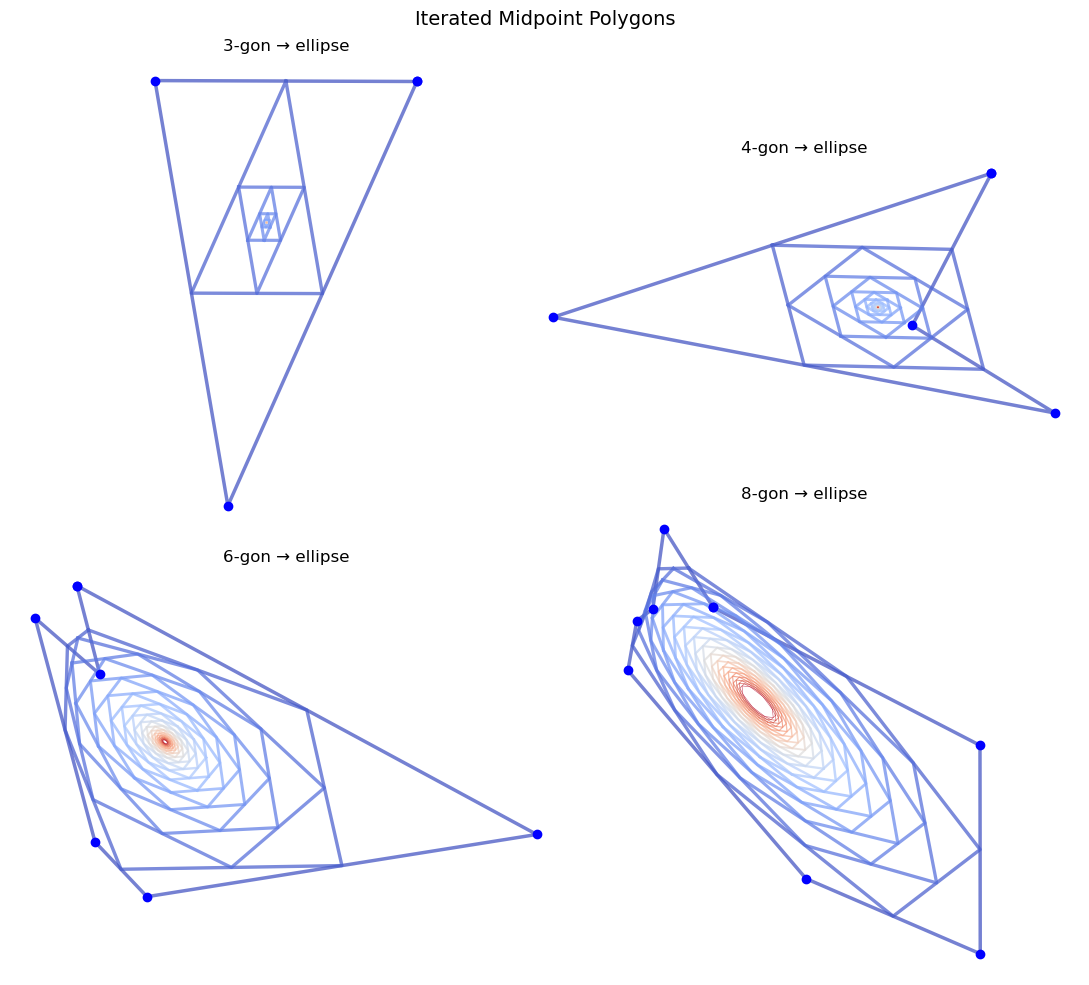

In [3]:
k_list = [3, 4, 6, 8]
n_show = 30

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, k_val in zip(axes.ravel(), k_list):
    rng_k = np.random.default_rng(k_val)
    # Random k-gon
    angles = np.sort(rng_k.uniform(0, 2*np.pi, k_val))
    radii = 0.3 + 0.7 * rng_k.random(k_val)
    z_init = radii * np.exp(1j * angles)
    polys_k = iterate_polygon(z_init, n_show)

    cols = plt.cm.coolwarm(np.linspace(0, 1, n_show + 1))
    for poly, col, idx in zip(polys_k, cols, range(n_show+1)):
        lw = max(0.4, 2.5 - 0.07*idx)
        z_c = np.append(poly, poly[0])
        ax.plot(z_c.real, z_c.imag, '-', color=col, lw=lw, alpha=0.7)

    ax.plot(np.append(z_init.real, z_init.real[0]),
            np.append(z_init.imag, z_init.imag[0]), 'b.', ms=12)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{k_val}-gon → ellipse', fontsize=12)

plt.suptitle('Iterated Midpoint Polygons', fontsize=14)
plt.tight_layout(); plt.savefig('multi_poly.png', dpi=100, bbox_inches='tight'); plt.show()

### Spectral analysis of the midpoint map

The eigenvalues of the circulant midpoint matrix are $\lambda_j = \cos(\pi j/k) e^{i\pi j/k}$ with magnitude $|\lambda_j| = \cos(\pi j/k)$. We plot how the Fourier modes of the polygon decay over iterations.

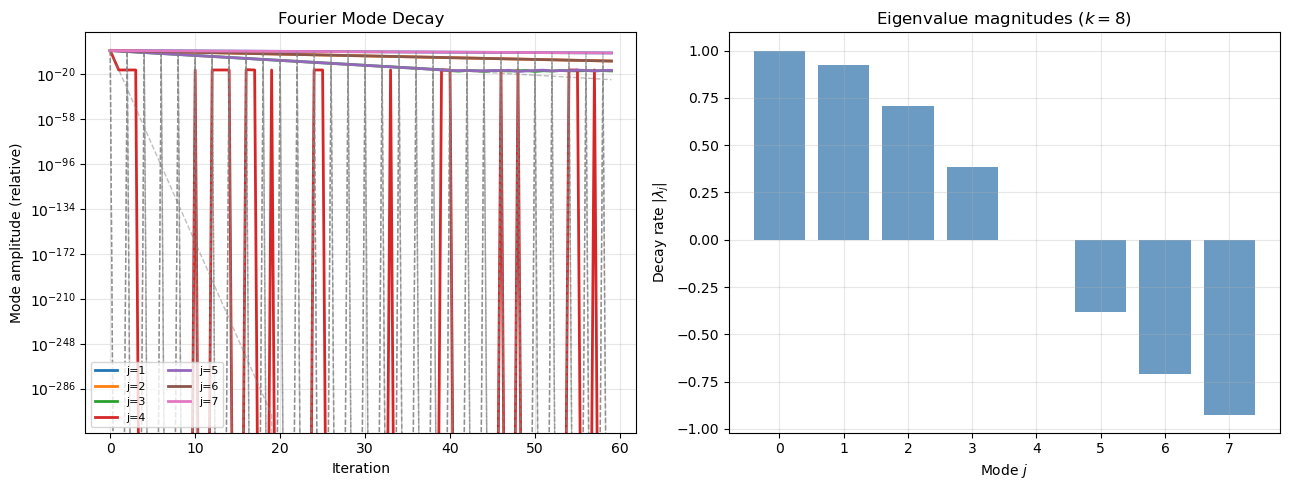

In [4]:
k_spec = 8
rng2 = np.random.default_rng(77)
z_spec = rng2.standard_normal(k_spec) + 1j * rng2.standard_normal(k_spec)

n_spec = 60
modes_over_time = []
z_cur = z_spec.copy()
for _ in range(n_spec):
    Z_hat = np.fft.fft(z_cur) / k_spec
    modes_over_time.append(np.abs(Z_hat))
    z_cur = midpoint_step(z_cur)

modes_over_time = np.array(modes_over_time)  # (n_spec, k)

# Theoretical decay rates
j_vals = np.arange(k_spec)
decay_rates = np.cos(np.pi * j_vals / k_spec)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for j in range(1, k_spec):
    m0 = modes_over_time[0, j] + 1e-12
    axes[0].semilogy(modes_over_time[:, j] / m0, lw=2, label=f'j={j}')
    t_arr = np.arange(n_spec)
    axes[0].semilogy(decay_rates[j]**t_arr, '--', lw=1, color='gray', alpha=0.5)

axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Mode amplitude (relative)')
axes[0].set_title('Fourier Mode Decay')
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(True, alpha=0.3)

axes[1].bar(j_vals, decay_rates, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Mode $j$'); axes[1].set_ylabel('Decay rate $|\\lambda_j|$')
axes[1].set_title(f'Eigenvalue magnitudes ($k={k_spec}$)')
axes[1].set_xticks(j_vals)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('spectral.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: vary $k$, iterations, and averaging parameter $s$

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 2, figsize=(10, 10))
    for ax, k_val in zip(axes.ravel(), k_list):
        rng_k = np.random.default_rng(k_val)
        angles = np.sort(rng_k.uniform(0, 2*np.pi, k_val))
        radii = 0.3 + 0.7 * rng_k.random(k_val)
        z_init = radii * np.exp(1j * angles)
        polys_k = iterate_polygon(z_init, n_show)
        cols = _plt.cm.coolwarm(np.linspace(0, 1, n_show + 1))
        for poly, col, idx in zip(polys_k, cols, range(n_show+1)):
            lw = max(0.4, 2.5 - 0.07*idx)
            z_c = np.append(poly, poly[0])
            ax.plot(z_c.real, z_c.imag, '-', color=col, lw=lw, alpha=0.7)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f'{k_val}-gon', fontsize=12)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The midpoint map is a **circulant linear operator**; its action is diagonalized by the DFT.
- All Fourier modes except the centroid and fundamental frequency decay exponentially — hence convergence to an **ellipse**.
- The rate of convergence of mode $j$ is $\cos(\pi j / k)$, so higher modes vanish faster.
- The general weighted average $(1-s) z_j + s z_{j+1}$ changes the decay rates but not the qualitative behavior.

## Bibliography

- P. J. Davis, *Circulant Matrices*, Wiley, 1979.
- A. S. Cavaretta, W. Dahmen & C. A. Micchelli, *Stationary subdivision*, Memoirs AMS 93, 1991.
- N. Dyn, *Subdivision schemes in CAGD*, Advances in Numerical Analysis II, 1992.